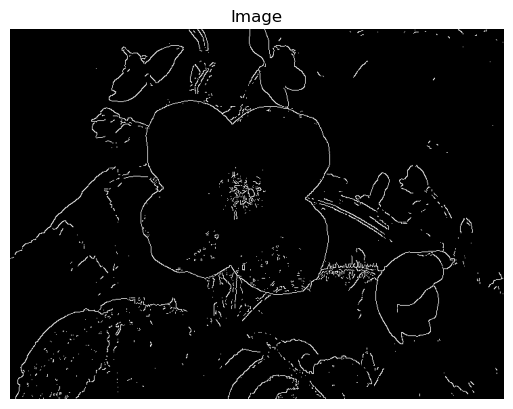

In [4]:
import cv2
import numpy as np
import random
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
imgInfo = img.shape
height = imgInfo[0]
width = imgInfo[1]
#canny 1 gray 2 高斯 3 canny
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
imgG = cv2.GaussianBlur(gray,(3,3),0)
dst = cv2.Canny(img,200,200) #图片卷积——》th
import matplotlib.pyplot as plt
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Image')
plt.axis('off')
plt.show()


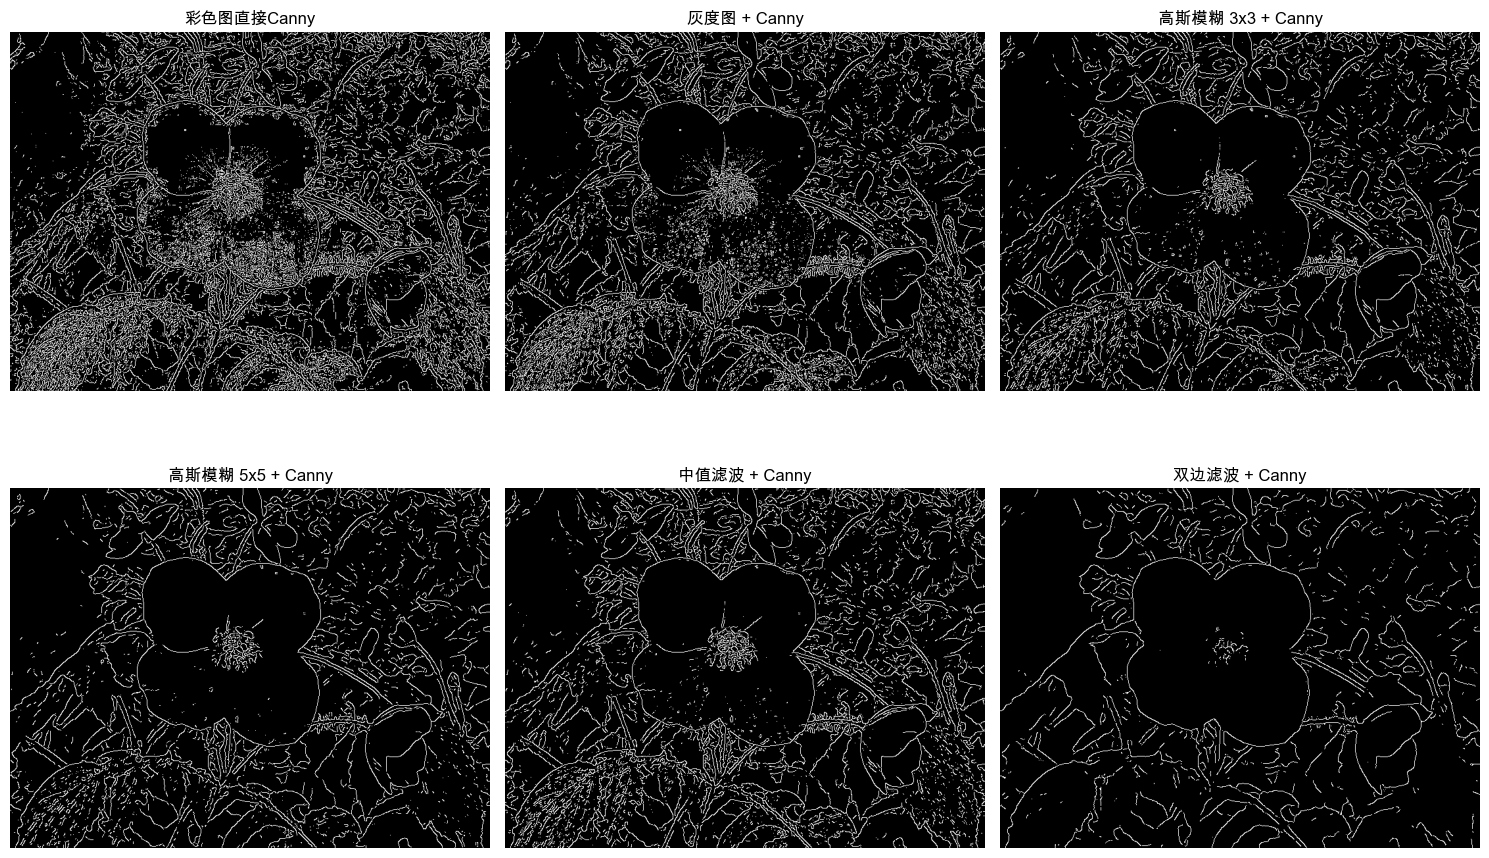

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 不同预处理方式
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 原图直接Canny（彩色图会出错）
try:
    dst0 = cv2.Canny(img, 50, 50)
except:
    dst0 = np.zeros_like(gray)
    axes[0, 0].text(50, 150, '错误: 需要灰度图', color='red', fontsize=14)
axes[0, 0].imshow(dst0, cmap='gray')
axes[0, 0].set_title('彩色图直接Canny')
axes[0, 0].axis('off')

# 2. 灰度图直接Canny（无模糊）
dst1 = cv2.Canny(gray, 50, 50)
axes[0, 1].imshow(dst1, cmap='gray')
axes[0, 1].set_title('灰度图 + Canny')
axes[0, 1].axis('off')

# 3. 灰度图 + 高斯模糊（3x3）
imgG1 = cv2.GaussianBlur(gray, (3, 3), 0)
dst2 = cv2.Canny(imgG1, 50, 50)
axes[0, 2].imshow(dst2, cmap='gray')
axes[0, 2].set_title('高斯模糊 3x3 + Canny')
axes[0, 2].axis('off')

# 4. 灰度图 + 高斯模糊（5x5）
imgG2 = cv2.GaussianBlur(gray, (5, 5), 0)
dst3 = cv2.Canny(imgG2, 50, 50)
axes[1, 0].imshow(dst3, cmap='gray')
axes[1, 0].set_title('高斯模糊 5x5 + Canny')
axes[1, 0].axis('off')

# 5. 灰度图 + 中值滤波
imgM = cv2.medianBlur(gray, 3)
dst4 = cv2.Canny(imgM, 50, 50)
axes[1, 1].imshow(dst4, cmap='gray')
axes[1, 1].set_title('中值滤波 + Canny')
axes[1, 1].axis('off')

# 6. 灰度图 + 双边滤波
imgB = cv2.bilateralFilter(gray, 9, 75, 75)
dst5 = cv2.Canny(imgB, 50, 50)
axes[1, 2].imshow(dst5, cmap='gray')
axes[1, 2].set_title('双边滤波 + Canny')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()